# Corpus Exploration 


## 1. Imports and NLTK data
this rely heavily from helpers in ngram.py


In [6]:
import nltk
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Make sure the corpora are available (no-op if already downloaded).
for pkg in ['brown', 'reuters', 'punkt', 'punkt_tab']:
    try:
        nltk.download(pkg, quiet=True)

    except Exception as e:

        print('download warning:', pkg, e)

from Ngram import load_sentences, build_vocab
print('Setup complete. NLTK corpora are available')


Setup complete. NLTK corpora are available


In [3]:
#download the necessary NLTK corpora
import nltk

nltk.download('brown')
nltk.download('reuters')
nltk.download('punkt')




[nltk_data] Downloading package brown to /Users/keigo/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package reuters to /Users/keigo/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to /Users/keigo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
brown_sents = load_sentences(['brown'])
reuters_sents = load_sentences(['reuters'])
all_sents = brown_sents + reuters_sents

print(f'Brown sentences  : {len(brown_sents):>8,}')
print(f'Reuters sentences: {len(reuters_sents):>8,}')
print(f'Combined         : {len(all_sents):>8,}')
print()
print('Example tokenized sentence:')
print(all_sents[0][:20], '...')


Brown sentences  :   57,101
Reuters sentences:   54,711
Combined         :  111,812

Example tokenized sentence:
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took'] ...


## Tokens Statistics


In [7]:
tokens = [w for sent in all_sents for w in sent]
counter = Counter(tokens)

n_tokens = len(tokens)
n_types = len(counter)
hapax = sum(1 for w, c in counter.items() if c == 1)

print(f'Total tokens (running words) : {n_tokens:>10,}')
print(f'Vocabulary size (word types) : {n_types:>10,}')
print(f'Type/token ratio             : {n_types / n_tokens:>10.4f}')
print(f'Hapax legomena (seen once)   : {hapax:>10,} '
      f'({100 * hapax / n_types:.1f}% of vocab)')
print()
print('Top 20 most frequent tokens:')
for w, c in counter.most_common(20):
    print(f'  {w:<10} {c:>8,}')

Total tokens (running words) :  2,465,187
Vocabulary size (word types) :     57,611
Type/token ratio             :     0.0234
Hapax legomena (seen once)   :     21,464 (37.3% of vocab)

Top 20 most frequent tokens:
  the         139,248
  of           73,191
  to           62,558
  and          54,501
  in           50,590
  a            48,298
  said         27,344
  for          23,271
  it           19,864
  mln          18,623
  that         18,134
  is           17,777
  on           15,985
  s            15,702
  was          15,631
  he           14,763
  vs           14,345
  with         13,468
  be           12,734
  from         12,587


## Zipf's Law - Frequency distribution

the law stated that  is an empirical observation stating that in many large datasets, the frequency of any item is inversely proportional to its rank in the frequency table . When items are sorted from most to least common, the n-th most frequent item appears  times as often as the most frequent item .

link: https://masoudbahrami.medium.com/zipfs-law-a-universal-pattern-in-our-data-driven-world-4d6c564d848c


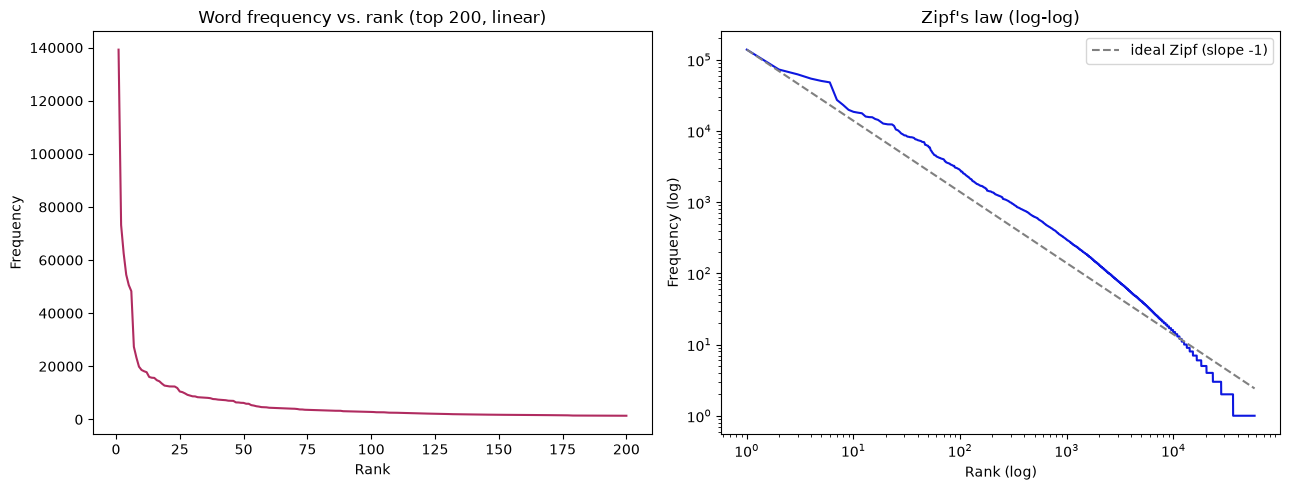

In [15]:
ranks = np.arange(1, n_types + 1)
freqs = np.array([c for _, c in counter.most_common()])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale — shows the brutal drop-off.
axes[0].plot(ranks[:200], freqs[:200], color="#b02b60")
axes[0].set_title('Word frequency vs. rank (top 200, linear)')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

# Log-log scale — Zipf's near-straight line.
axes[1].loglog(ranks, freqs, color="#0d17e0")
ideal = freqs[0] / ranks  # ideal Zipf slope -1 anchored at top word
axes[1].loglog(ranks, ideal, '--', color='gray', label='ideal Zipf (slope -1)')
axes[1].set_title("Zipf's law (log-log)")
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

## How Much text the top-k words explain

words that are Frequent

Top    100 words cover  45.2% of all tokens
Top  1,000 words cover  72.3% of all tokens
Top  5,000 words cover  88.9% of all tokens
Top 10,000 words cover  93.9% of all tokens


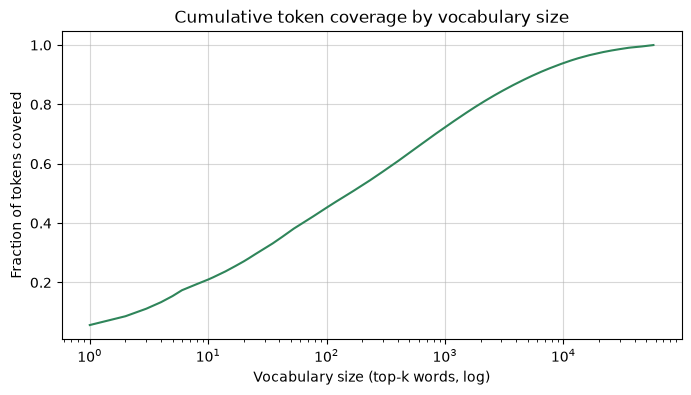

In [20]:
cum = np.cumsum(freqs) / n_tokens
for k in [100, 1000, 5000, 10000]:
    if k <= len(cum):
        print(f'Top {k:>6,} words cover {100 * cum[k - 1]:5.1f}% of all tokens')

plt.figure(figsize=(8, 4))
plt.plot(ranks, cum, color='#2f855a')
plt.xscale('log')
plt.title('Cumulative token coverage by vocabulary size')
plt.xlabel('Vocabulary size (top-k words, log)')
plt.ylabel('Fraction of tokens covered')
plt.grid(True, alpha=0.5)
plt.show()

In [21]:
## Minimum vocabulary size for 90% coverage
for mc in [1, 2, 5, 10]:
    v = build_vocab(all_sents, min_count=mc)
    print(f'min_count={mc:>2} -> vocabulary size {len(v):>8,}')

min_count= 1 -> vocabulary size   57,614
min_count= 2 -> vocabulary size   36,150
min_count= 5 -> vocabulary size   20,367
min_count=10 -> vocabulary size   13,316


## 📄 Copyright

© 2026 Matthew Ferrer (Keigo). All Rights Reserved.

This project was created for educational and portfolio purposes as part of my Data Science learning journey.

You are welcome to:
- ⭐ View and learn from the source code.
- 🍴 Fork this repository for personal, educational, or non-commercial use.
- 💡 Use the ideas and techniques with proper attribution.

You may **not**:
- Republish or redistribute this project as your own.
- Remove or alter this copyright notice.
- Use this project or substantial portions of its source code for commercial purposes without prior written permission.

If you use this project as a reference, please provide appropriate credit by linking back to this repository.

Thank you for respecting the work and effort invested in this project.